<center><h1><font color='darkblue'>Elektrotehnički fakultet Beograd</font></h1></center>

# Oscilacije, 2025. godina

Luka Puco 24/0091

<font color='red'>
Preimenovati svesku: File/Rename u [1] oscilacije_ime_prezime<br>
Redovno snimati aktuelnu verziju sveske.<br>
Preuzimanje fajla: Download as Notebook (.ipynb) </font>

### __Zadatak 1__: 
Posmatra se telo mase $m$ vezano za idealnu oprugu krutosti $k$, koje se kreće po glatkoj horizontalnoj podlozi duž $x$ ose. Na telo deluje otporna sila čiji je intenzitet srazmeran brzini $v$. Poznate su vrednosti sopstvene kružne učestanosti $\omega_0$, faktora prigušenja $\alpha$, početne pozicije u kojoj se nalazi telo $x_0$ i početne brzine $v_0$.

a) Formirati Python definiciju __prigusene__ koja modeluje zadati problem i omogućava rešavanje diferencijalne jednačine primenom integrate.odeint metode. Funkcija poziva parametre $\omega_0$ i $\alpha$.

In [1]:
def prigusene(y,t,omega0,alpha):
    y1,y2=y
    return [y2, -(omega0**2)*y1 - 2*alpha*y2]

b) Napisati komande koje uvoze modul numpy, modul matplotlib.pyplot i funkciju za integraciju iz scipy modula.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

c) Definisati vrednosti sopstvene kružne učestanosti $ω_0 = 1$ rad/s, i listu četiri različite vrednosti koje uzima faktor prigušenja: $α_1 = ω_0$, $α_2 = ω_0/10$, $α_3 = 15ω_0$ i $α_4 = 0$. <br>
Definisati početne uslove: telo se u početnom trenutku nalazi na rastojanju $x_0 = 10$ m od ravnotežnog položaja i ima brzinu $v_0 = 20$ m/s.<br>
Definisati vremensku osu: $0$ do $60$ sekundi u $1000$ ekvidistantnih tačaka.

In [4]:
omega0 = 1
alpha = [omega0, omega0/10, 15*omega0, 0]
x0 = 10
v0 = 20
vreme = np.linspace(0,60,1000)

d) Napisati kod koji omogućava da se u okviru istog Figure prozora korišćenjem naredbe subplot, iscrtaju vremenski odzivi $x(t)$ za sve četiri vrednosti faktora prigušenja. Označiti ose grafika (“vreme [s]” i “x(t) [m]”). Na graficima prikazati legendu koja se odnosi na odgovarajuću vrednost faktora prigušenja $α$.<br>
_Da bi se prikazao grafik potrebno je izvršiti komandu plt.show()_

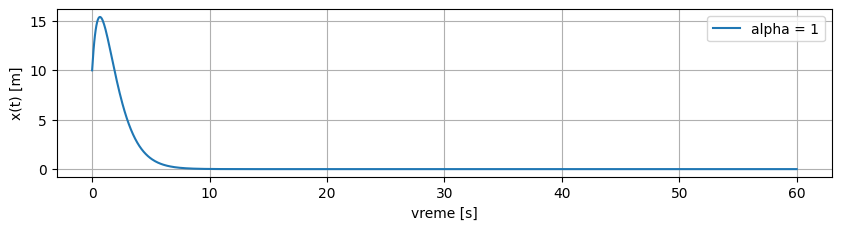

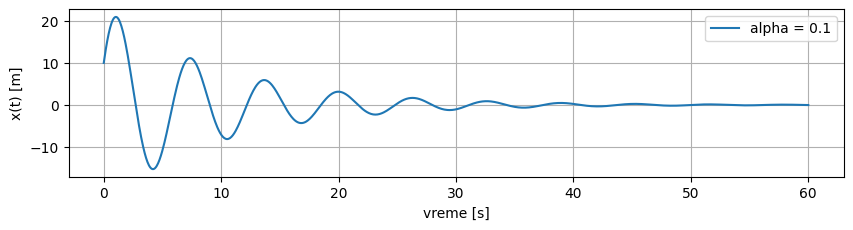

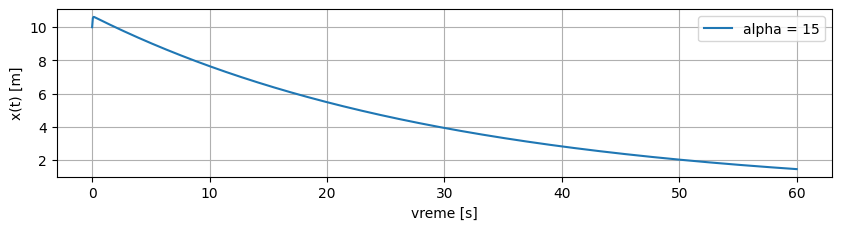

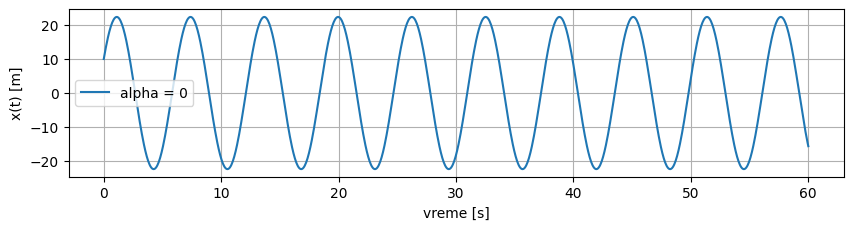

In [5]:
for ink,value in enumerate(alpha):
    resenje = integrate.odeint(prigusene,[x0,v0],vreme,args=(omega0,value))
    plt.figure(figsize=(10,10))
    plt.subplot(4,1,ink+1)
    plt.plot(vreme,resenje[:,0],label='alpha = '+str(value))
    plt.xlabel('vreme [s]')
    plt.ylabel('x(t) [m]')
    plt.legend()
    plt.grid()
    # x(t) je cela prva kolona matrice resenje
plt.show()  

e) Napisati kod koji omogućava da se u okviru istog Figure prozora korišćenjem naredbe subplot, iscrtaju fazni dijagrami za sve četiri vrednosti faktora prigušenja. Označiti ose grafika (“x [m]” i “v [m/s]”). Na graficima prikazati legendu koja se odnosi na odgovarajuću vrednost faktora prigušenja  $α$ .

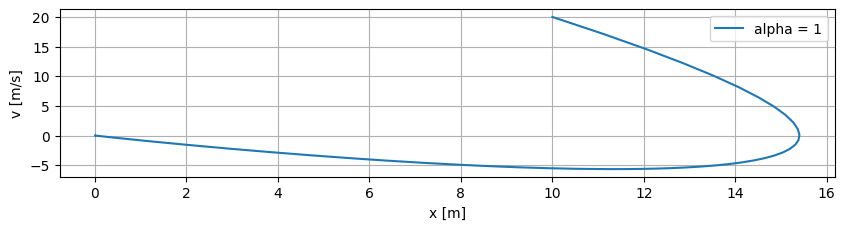

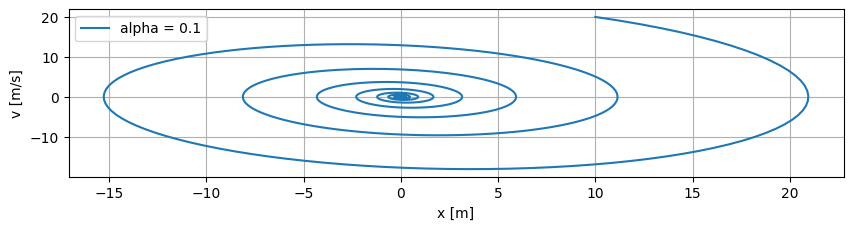

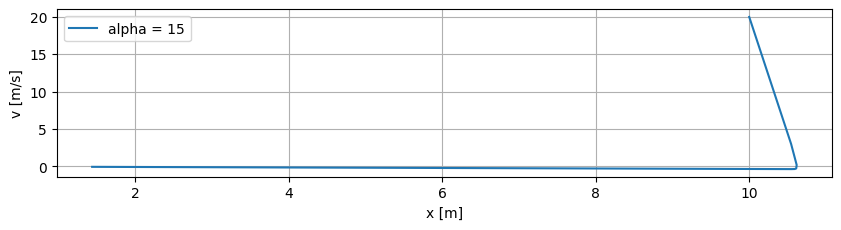

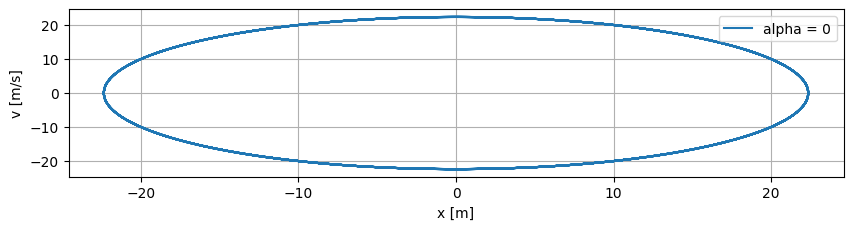

In [6]:
for ink,value in enumerate(alpha):
    resenje = integrate.odeint(prigusene,[x0,v0],vreme,args=(omega0,value))
    plt.figure(figsize=(10,10))
    plt.subplot(4,1,ink+1)
    plt.plot(resenje[:,0],resenje[:,1],label='alpha = '+str(value))
    plt.xlabel('x [m]')
    plt.ylabel('v [m/s]')
    plt.legend()
    plt.grid()
    # x(t) je cela prva kolona matrice resenje
plt.show() 

f) Na osnovu prethodna dva grafika odrediti tip oscilacija za svaku od vrednosti koeficijenta prigušenja. Proceniti vremenski trenutak u kom se dostiže stacionarno stanje (ako se dostiže) i navesti ga za svaki od prikazanih grafika. Dodatno, za svaki tip oscilacija prokomentarisati i ukratko prodiskutovati oblik faznog dijagrama.

Prvi grafik predstavlja kritično prigušenje jer je alfa isto što i Wo. Oko desete sekunde se ulazi u stacionarno stanje, relativno brzo se kretanje završava.
Drugi grafik telo sve vreme osciluje i on predstavlja slabo prigušenje, jer je alfa manje od Wo. Telo se sve manje i manje osciluje, pa oko 43 sekunde ulazimo u stacionarno stanje, jer tad počinju male oscilacije.
Treći grafik predstavlja jako prigušenje, njegov koeficijent kočenja, alfa, je 15 puta veći od W0. on se ne zaustavlja, za razliku od kriticnog prigušenja, ali je jako blizu nuli.
Četvrti grafik predstavlja neprigušeno oscilatorno kretanje, pa nema gubitaka.

g) Napisati kod koji omogućava da se na istom dijagramu iscrtaju zavisnost kinetičke (plavom bojom) i potencijalne energije (crvenom bojom) sistema od vremena $t$ za faktor prigušenja $α = ω_0/10$, ako je masa tela koje osciluje $m = 1 $kg.

In [17]:
alfa=omega0/10
m=1
k=np.power(omega0,2)*m
sol=integrate.odeint(prigusene,[x0,v0],vreme,args=(omega0,alfa))
Ep=0.5*k*sol[:,0]**2
Ek=0.5*m*sol[:,1]**2
plt.figure(figsize=(6,4))
plt.plot(vreme,Ep,label='Ep',color="red")
plt.plot(vreme,Ek,label='Ek',color="blue")


NameError: name 'prigusene' is not defined

h) Napisati kod koji omogućava da se iscrta zavisnost ukupne energije sistema za parametre kao u prethodnoj tački (tačka g)) i komentarisati dobijeni grafik. Zašto grafik nije glatka, opadajuća funkcija?

Text(0, 0.5, 'E [J]')

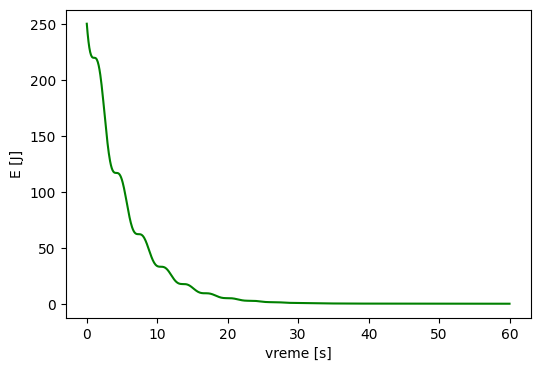

In [19]:
plt.figure(figsize=(6,4))
plt.plot(vreme,Ep+Ek,color="green")
plt.xlabel('vreme [s]')
plt.ylabel('E [J]')

Energija konstantno opada zbog prigušenja u kolu dok ne opadne do nule gde se završava pad. Grafik nije savršeno glatka opadajuća funkcija zbog numeričkih grešaka koje nastaju pri rešavanju diferencijalnih jednačina metodom konačnih koraka.

***
<font color='red'>Snimiti aktuelnu verziju sveske.<br></font>
***

### __Zadatak 2__: 
Posmatra se telo mase $m$ vezano za idealnu oprugu krutosti $k$, koje se kreće po glatkoj horizontalnoj podlozi duž $x$ ose. Na telo deluje otporna sila čiji je intenzitet srazmeran brzini $v$ i spoljašnja harmonijska sila amplitude $F_0$ i kružne učestanosti $Ω$ koja ima za cilj da kompenzuje disipaciju energije u ovom sistemu. Poznate su vrednosti sopstvene kružne učestanosti $ω_0$, faktora prigušenja $α$, početne pozicije u kojoj se nalazi telo $x_0$ i početne brzine $v_0$.

a) Formirati Python definiciju __prinudne__ koja modeluje zadati problem i omogućava rešavanje diferencijalne jednačine primenom integrate.odeint metode. Funkcija poziva parametre $\omega_0$, $\alpha$, $F_0$, $m$ i $Ω$.

In [3]:
def prinudne(y,t,omega0,alfa,F0,m,omega):
    y1,y2=y
    return[y2,F0/m*np.sin(omega*t)-(omega0**2)*y1 - 2*alfa*y2]

b) Napisati komande koje uvoze modul numpy, modul matplotlib.pyplot i funkciju za integraciju iz scipy modula 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

c) Poznate su vrednosti sopstvene kružne učestanosti $ω_0 = 10$ rad/s, faktora prigušenja $α = ω_0/20$, amplitude $F_0 = 20$ N i kružne učestanosti $Ω = 2$ rad/s prinudne sile. Masa tela je $m = 1$ kg.<br>
Definisati početne uslove: Telo u početnom trenutku miruje na rastojanju $x_0 = 10$ m od ravnotežnog položaja.<br>
Definisati vremensku osu: $0$ do $60$ sekundi u $6000$ ekvidistantnih tačaka.

In [5]:
x0 = 10
v0 = 0
omega0 = 10
alfa = omega0 / 20
Fo = 20
omega = 2
m = 1

vreme=np.linspace(0,60,6000)
resenje = integrate.odeint(prinudne,[x0,v0],vreme,args=(omega0,alfa,Fo,m,omega))

d) Napisati kod koji omogućava da se iscrta grafik vremenskog odziva $x(t)$. Označiti ose grafika (“vreme [s]” i “x(t) [m]”). 

Text(0, 0.5, 'x(t) [m]')

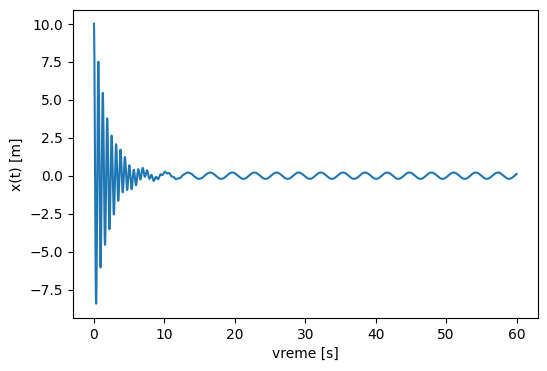

In [6]:
plt.figure(figsize=(6,4))
plt.plot(vreme,resenje[:,0])
plt.xlabel('vreme [s]')
plt.ylabel('x(t) [m]')

e) Napisati kod koji omogućava da se iscrta fazni dijagram $v(x)$. Označiti ose grafika (“x(t) [m]” i “v(t) [m/s]”). 

Text(0, 0.5, 'v(t) [m/s]')

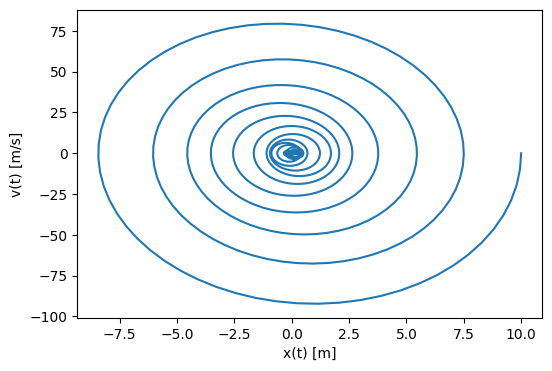

In [7]:
plt.figure(figsize=(6,4))
plt.plot(resenje[:,0],resenje[:,1])
plt.xlabel('x(t) [m]')
plt.ylabel('v(t) [m/s]')

f) Šta se uočava na faznom dijagramu u trenutku kada u vremenskom odzivu preostaju samo oscilacije kao posledica prinudne sile? Napisati kod koji omogućava da se iscrta dodatni grafik, zumirani fazni dijagram, tako da limiti za $x$ osu budu od $-0.5$ do $0.5$, a za $y$ osu od $-4$ do $4$. 

(-4.0, 4.0)

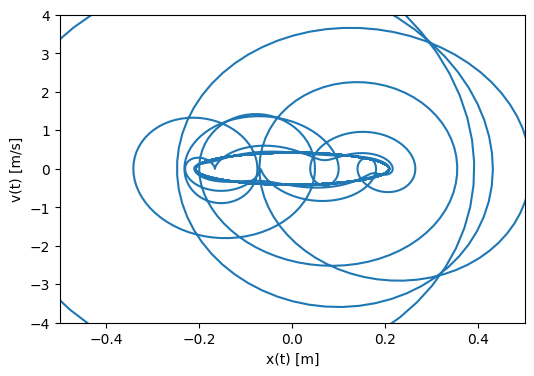

In [8]:
plt.figure(figsize=(6,4))
plt.plot(resenje[:,0],resenje[:,1])
plt.xlabel('x(t) [m]')
plt.ylabel('v(t) [m/s]')
plt.xlim(-0.5, 0.5)
plt.ylim(-4, 4)

Kad prođu slobodne oscilacije, fazna trajektorija se više ne približava nuli, već se zatvara u elipsu. To je stacionarni režim prinudnih oscilacija jer sada samo deluje prinudna sila.

g) Neka se frekvencija prinudne sile menja u opsegu frekvencija $Ω = [0, 2ω_0]$ sa korakom $ω_0/50$. Napisati kod koji omogućava da se iscrta amplitudska karaterisktika prinudnog odziva $A(Ω)$ koristeći se analitičkim izrazom za amplitudsku karakteristiku (sa slajdova). Označiti ose grafika (“učestanost prinudne sile” i “amplituda prinudnih oscilacija”). Prikazati legendu "analitička metoda".

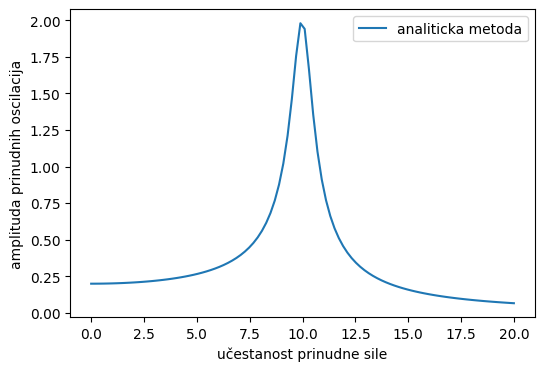

In [11]:
omega=np.linspace(0,2*omega0,100)
plt.figure(figsize=(6,4))
A=(Fo/m)/np.sqrt((omega0**2-omega**2)**2+(2*alfa*omega)**2)
plt.plot(omega,A,label="analiticka metoda")
plt.xlabel("učestanost prinudne sile")
plt.ylabel("amplituda prinudnih oscilacija")
plt.legend()


h) Napisati kod koji omogućava numeričko određivanje amplitudske karakteristike. Iscrtati amplitudsku karaterisktiku dobijenu numeričkom metodom (isprekidanom crvenom linijom). Označiti ose grafika (“učestanost prinudne sile” i “amplituda prinudnih oscilacija”). Prikazati legendu "numerička metoda".<br>
_Hint:_ Rešiti jednačinu za svako $Ω$ iz opsega $[0, 2ω_0]$ na vremenskoj osi od $0$ do $300$ sekundi u $2000$ ekvidistantnih tačaka. Vremenska osa je produžena da bi bili sigurni da je sistem dostigao stacionarno stanje, tj. da je prelazni režim u kom postoje prigušene oscilacije završen. Amplituda oscilacija u stacionarnom odzivu se može naći kao maksimalni element niza na zadatom vremenskom intervalu. 

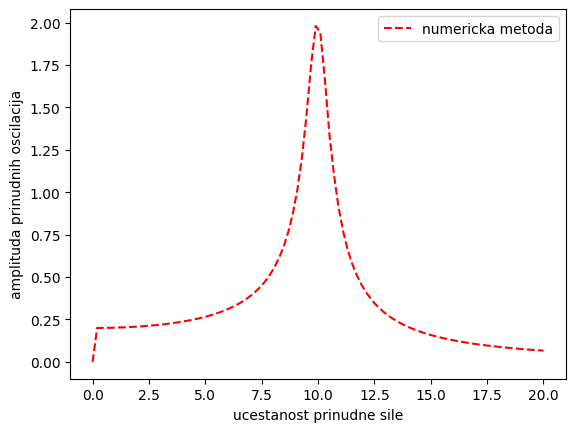

In [12]:
A_numericka=[]
t=np.linspace(0,300,2000)
for o in omega:
    resenje=integrate.odeint(prinudne,[x0,v0],t,args=(omega0,alfa,Fo,m,o))
    x=resenje[:,0]
    stac=x[int(0.9*len(x)):]
    A_numericka.append(np.max(np.abs(stac)))
plt.figure()
plt.xlabel("ucestanost prinudne sile")
plt.ylabel("amplituda prinudnih oscilacija")
plt.plot(omega,A_numericka,"r--",label="numericka metoda")
plt.legend()

i)	Napisati kod koji omogućava da se iz numerički dobijene amplitudske karakteristike odredi pri kojoj frekvenciji pobudne sile numerička kriva dostiže maksimalnu vrednost. Ova vrednost frekvencije naziva se rezonantna frekvencija. Prikazati numerički određenu vrednost za rezonantnu učestanost. Prikazati vrednost za rezonantnu učestanost koja se dobija na osnovu analitičkog izraza prikazanog na slajdovima. Izračunati relativno odstupanje za rezonantnu učestanost određenu numerički u odnosu na učestanost određenu na osnovu analitičkog izraza. 

In [16]:
numericki_rez_index=np.argmax(A_numericka)
numericki_rez=omega[numericki_rez_index]
analiticki_rez=np.sqrt(omega0**2-2*alfa**2)
print("numericka rezonantna ucestanost je {}".format(numericki_rez))
print("analiticki rezonantna ucestanost je {}".format(analiticki_rez))

relativno_odstupanje=(analiticki_rez-numericki_rez)/numericki_rez*100
print("relativno odstupanje je:{}%".format(relativno_odstupanje))

numericka rezonantna ucestanost je 9.8989898989899
analiticki rezonantna ucestanost je 9.974968671630002
relativno odstupanje je:0.7675406623847061%
